<a href="https://colab.research.google.com/github/abbiddo/retention-analysis/blob/main/student_retention_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retention Rate Analysis


> 운영 데이터를 기반으로 재수강률 변동 요인을 분석하고, 데이터 기반 운영 의사결정을 지원하기 위한 EDA 프로젝트


# Table of Contents

1. Project Overview
2. Data Preprocessing
3. Analysis 1. 월별 재수강률 추이
4. Analysis 2. 학년별 월별 재수강률 추이
5. Analysis 3. 결제 기간별 재수강률
6. Analysis 4. 월별 환불률 및 미연장률 추이
7. Conclusion
8. Business Impact



---



## Project Overview

### Background
- 팀별 재수강률 편차가 발생할 경우 동일한 운영 액션이 적용되고 있었다.
- 이에 재수강률 변동이 특정 시기나 단일 요인에 의해 발생하는지 확인하고, 다양한 관점에서 원인을 분석하여 운영 개선에 활용할 수 있는 인사이트를 도출하고자 하였다.

### Goal
- 월별 재수강률 추이 및 변동 패턴 확인
- 학년, 결제 기간, 이탈 유형별 재수강률 차이 분석
- 재수강률 변동 요인 탐색
- 데이터 기반 운영 개선 인사이트 도출



---



## Import Data

In [ ]:
# 환경 세팅

!apt-get -qq install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumBarunGothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# google 계정 연동

from google.colab import auth
auth.authenticate_user()

In [ ]:
# drive mount

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

In [ ]:
# 결제 내역 데이터 불러오기

import pandas as pd
from datetime import datetime

today = datetime.today().date()
today = str(today)
today = today[:4]+'_'+today[5:7]+'_'+today[8:]
print(today)

file_name = "payment_data" + '.csv'
print(file_name)

file_path = "/content/drive/MyDrive/data/" + file_name

df = pd.read_csv(file_path, encoding="utf-8-sig")

## Data Preprocessing

### Dataset

- 분석 기간: 2024-04 ~ 2026-04
- 기준 데이터: 계산일 기준 운영 데이터
- 주요 컬럼:
    - 계약상태
    - 상품명
    - 학년
    - 계산일

### Pre processing

- 수학 정규 수업 데이터만 사용
- 개강 전 환불, 취소, 폐지 등 분석 대상 제외
- 계약 상태를 연장완료 / 환불 / 미연장으로 표준화
- 계산일 기준 월 컬럼 생성
- 데이터 안정화 이전(~ 24-03) 및 미완료 월(26-05 ~) 데이터 제외

In [ ]:
# 분석 대상 컬럼 선택
df = df[['계약상태', '상품명', '학년', '과목', '권한시작일', '계산일', '개강전환불']]
df = df[df['과목'].isin(['수학'])]

exclude = ['취소', '폐지']
pattern = '|'.join(exclude)

df = df[df['개강전환불'] != 1]
df = df[~df['계약상태'].str.contains(pattern, na=True)]

exclude_products = ['프로모션', '체험']
pattern = '|'.join(exclude_products)

df = df[~df['상품명'].str.contains(pattern, na=True)]

# 계약 상태 표준화
df['상태'] = df['계약상태']
df.loc[df['계약상태'].str.contains('전환', na=False), '상태'] = '연장완료'
df.loc[df['계약상태'] == '환불신청', '상태'] = '환불'

# 계산일 기준 월 컬럼 생성 및 데이터 제외
df['월'] = pd.to_datetime(df['계산일']).dt.strftime('%y-%m')
df = df[(df['월'] >= '24-04') & (df['월'] <= '26-04')]

## Analysis 1. 월별 재수강률 추이

### Hypothesis
- 학사 일정 및 시즌에 따라 재수강률 차이가 존재할 수 있음

### Check Points
- 월별 재수강률 변화
- 특정 기간 상승/하락 패턴 존재 여부

In [ ]:
df_month = df.copy()
df_month['연장여부'] = (df_month['상태'] == '연장완료').astype(int)

df_monthly = df_month.groupby('월').agg(
    전체건수=('상태', 'count'),
    연장완료=('연장여부', 'sum')
).reset_index()

df_monthly['재수강률'] = (df_monthly['연장완료'] / df_monthly['전체건수'] * 100).round(1)

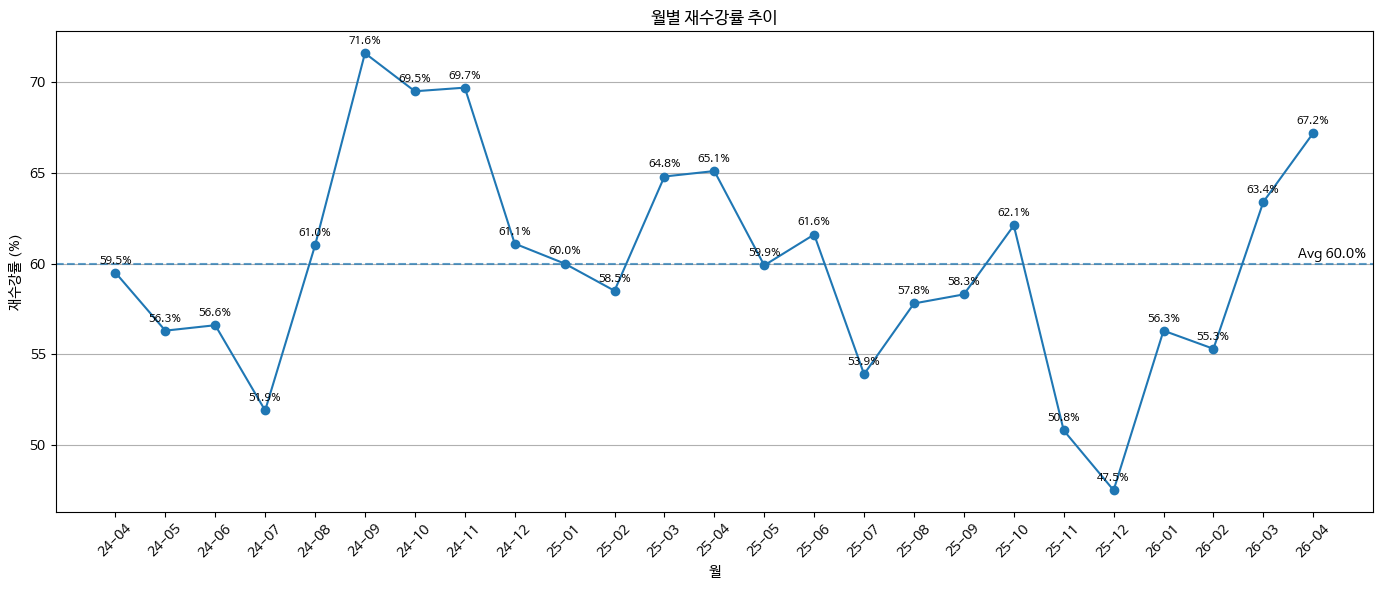

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df_monthly['월'],
    df_monthly['재수강률'],
    marker='o'
)

plt.title('월별 재수강률 추이')
plt.xlabel('월')
plt.ylabel('재수강률 (%)')

plt.xticks(rotation=45)
plt.grid(axis = 'y')

# 데이터 값 표시
for i, value in enumerate(df_monthly['재수강률']):
    plt.text(i,
    value + 0.5,
    f'{value:.1f}%',
    ha='center',
    fontsize=8
)

# 평균선 추가
avg_rate = df_monthly['재수강률'].mean()

plt.axhline(
    avg_rate,
    linestyle='--',
    alpha=0.7
)

plt.text(
    len(df_monthly)-1.3,
    avg_rate + 0.3,
    f'Avg {avg_rate:.1f}%'
)

plt.tight_layout()

plt.show()

### Observation

- 전체 평균 재수강률: 약 60.0%
- 학기 중 상승, 방학 중 하락 패턴을 가설로 세웠으나 연도별로 일관되지 않음
- 월별 변동폭이 비교적 크게 나타났으며, 특정 시기 재수강률 하락 구간도 확인됨
- 단순 계절성만으로 설명되지 않는 흐름 존재
- 단순 계절성 외 복합 요인 가능성 → 팀원별/상품별 분석으로 원인 탐색





---



## Analysis 2. 학년별 월별 재수강률 추이

### Hypothesis
- 학년별 재수강률은 학사 일정 및 시즌에 따라 차이가 존재할 수 있음
- 특히 고3은 수능 전후로 이탈이 집중될 수 있음


### Check Points
- 학년별 월별 재수강률 변화
- 전체 추이와의 차이 여부
- 특정 학년의 이탈 집중 시기 확인

In [ ]:
# 학년 정규화
def classify_grade(grade):
    if '초' in str(grade):
        return '초등'
    elif grade in ['N수생', '성인']:
        return 'N수생/성인'
    else:
        return grade

In [ ]:
# 학년별 월별 그룹화

df_monthly_grade  = df.copy()
df_monthly_grade ['연장여부'] = (df_monthly_grade['상태'] == '연장완료').astype(int)
df_monthly_grade['학년'] = df_monthly_grade['학년'].apply(classify_grade)

df_monthly_grade = df_monthly_grade.groupby(['월', '학년']).agg(
    전체건수=('상태', 'count'),
    연장완료=('연장여부', 'sum')
).reset_index()

df_monthly_grade['재수강률'] = (df_monthly_grade['연장완료'] / df_monthly_grade['전체건수'] * 100).round(1)

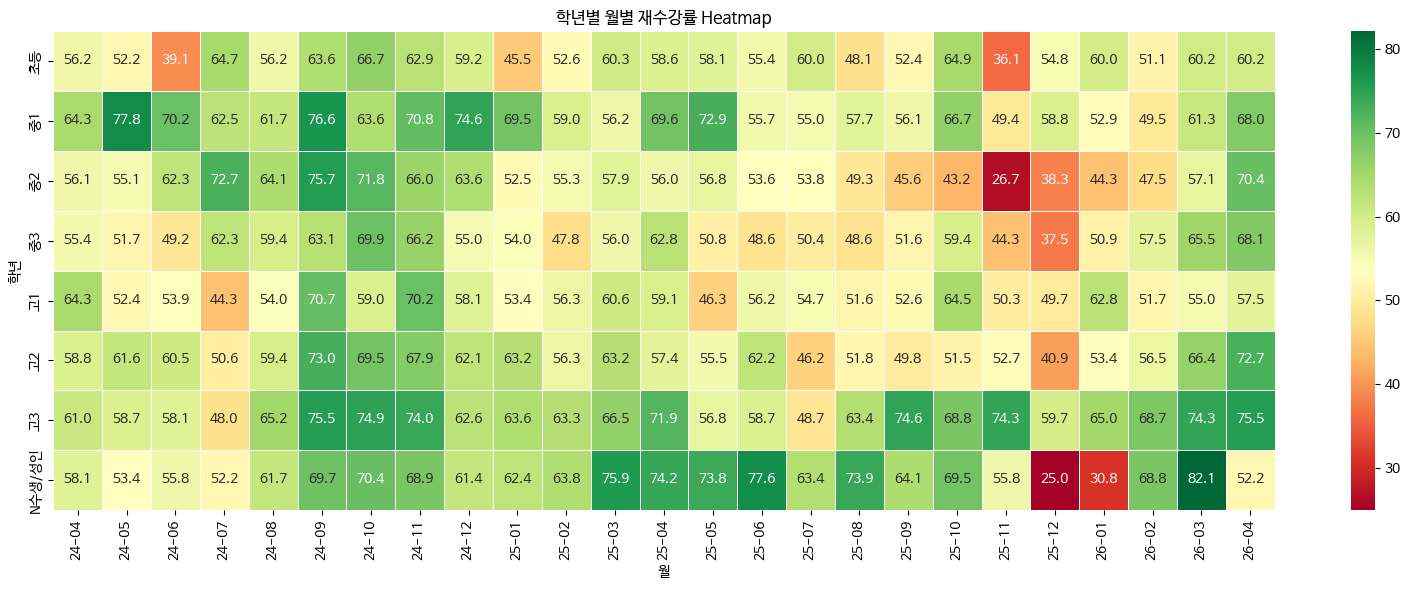

In [ ]:
# 학년별 월별 재수강률 heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap용 데이터
heatmap_data = df_monthly_grade.pivot(
    index='학년',
    columns='월',
    values='재수강률'
)

# 학년 순서 지정
grade_order = [
    '초등',
    '중1', '중2', '중3',
    '고1', '고2', '고3',
    'N수생/성인'
]

heatmap_data = heatmap_data.reindex(grade_order)

plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title('학년별 월별 재수강률 Heatmap')
plt.xlabel('월')
plt.ylabel('학년')

plt.tight_layout()
plt.show()

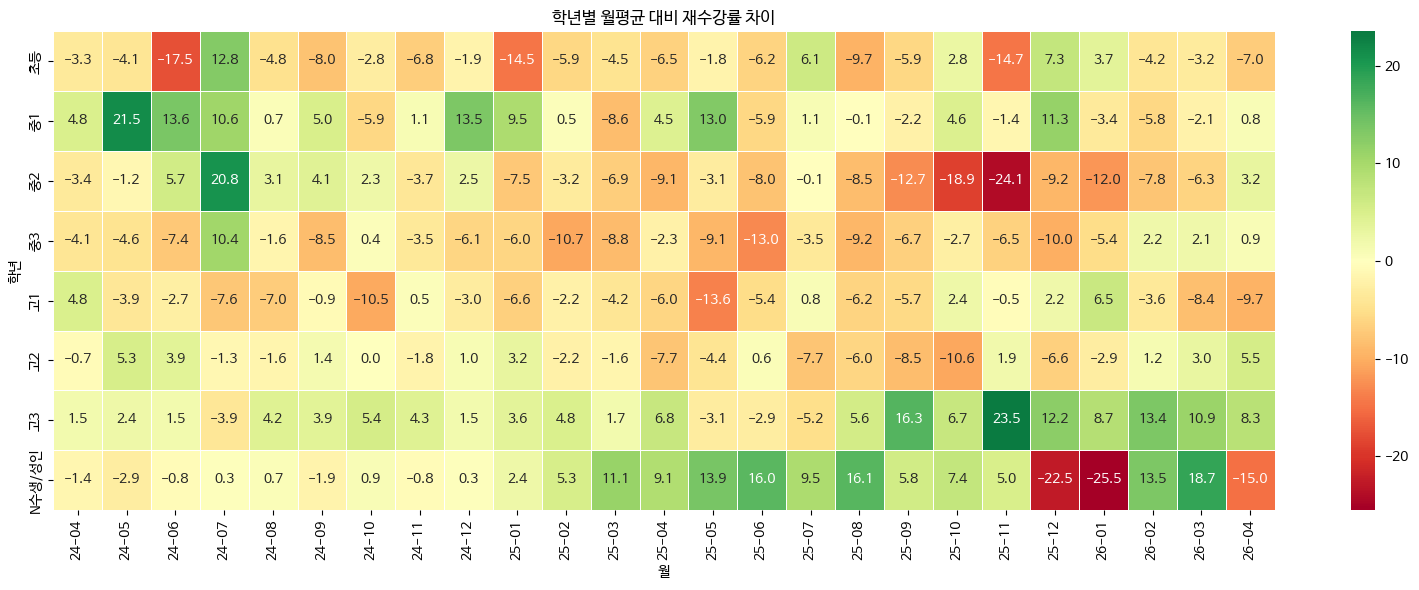

In [ ]:
# 학년별 월평균 대비 재수강률 차이 heatmqp

# 월별 전체 재수강률 (Anaysis1 에서 사용)
monthly_avg = df_monthly.set_index('월')['재수강률']

df_diff = df_monthly_grade.copy()
df_diff['월평균'] = df_diff['월'].map(monthly_avg)

# 평균 대비 차이 계산
df_diff['평균대비차이'] = (
    df_diff['재수강률']
    - df_diff['월평균']
).round(1)

# Heatmap용 Pivot
heatmap_diff = df_diff.pivot(
    index='학년',
    columns='월',
    values='평균대비차이'
)

# 학년 순서 정렬
grade_order = [
    '초등',
    '중1', '중2', '중3',
    '고1', '고2', '고3',
    'N수생/성인'
]

heatmap_diff = heatmap_diff.reindex(grade_order)

# 그리기
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_diff,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5
)

plt.title('학년별 월평균 대비 재수강률 차이')
plt.xlabel('월')
plt.ylabel('학년')

plt.tight_layout()
plt.show()

### Observation

- 대부분의 학년이 전체 재수강률과 유사한 상승/하락 패턴을 보임
- 특정 학년이 지속적으로 높거나 낮은 경향 없음
- 중2는 일부 기간에서 상대적으로 큰 하락폭을 보였으나, 운영상 이슈가 존재했던 시기와 일치
- N수생/성인 그룹은 수능 이후 재수강률 하락이 뚜렷하게 나타남
- 학년 변수만으로는 재수강률 변동을 설명하기 어려우며, 추가적인 요인 분석이 필요함 → 상품별 분석 진행




---



## Analysis 3. 결제 기간별 재수강률

### Hypothesis
- 결제 기간에 따라 재수강률 차이가 존재할 수 있음
- 장기 결제 상품은 계약 기간이 길어 연장 결제 시점이 늦어지므로 상대적으로 재수강률이 낮게 나타날 수 있음

### Check Points
- 결제 기간별 평균 재수강률
- 결제 기간에 따른 재수강률 차이
- 특정 결제 기간에서 재수강률 저하 여부 확인
- 결제 기간이 재수강률에 미치는 영향 탐색

In [ ]:
# 결제 기간 구분 함수
# 별도 컬럼이 존재하지 않아 상품명을 기반으로 결제기간 표준화
# 이외의 학습 기간은 특수 수업이므로 대상 제외 (기타)

def classify_payment_period(product_name):

    product_name = str(product_name)

    if ('4주' in product_name) or ('1개월' in product_name):
        return '4주'

    elif ('12주' in product_name) or ('3개월' in product_name):
        return '12주'

    elif ('24주' in product_name) or ('6개월' in product_name):
        return '24주'

    elif ('48주' in product_name) or ('12개월' in product_name) or ('1년' in product_name):
        return '48주'

    return '기타'

In [ ]:
# 결제 기간 데이터 전처리

df_payment_period = df.copy()

'''
기타 데이터 확인
valid_patterns = [
    '4w', '12w', '24w', '48w',
    '4주', '12주', '24주', '48주',
    '1개월', '3개월', '6개월', '12개월'
]

invalid_products = [
    product
    for product in df_payment_period['상품명'].unique()
    if not any(pattern.lower() in str(product).lower()
               for pattern in valid_patterns)
]

invalid_products
'''

df_payment_period['결제기간'] = (
    df_payment_period['상품명']
    .apply(classify_payment_period)
)

In [ ]:
df_payment_period ['재수강률'] = (df_payment_period['상태'] == '연장완료').astype(int)
df_payment_period.groupby('결제기간')['재수강률'].mean()

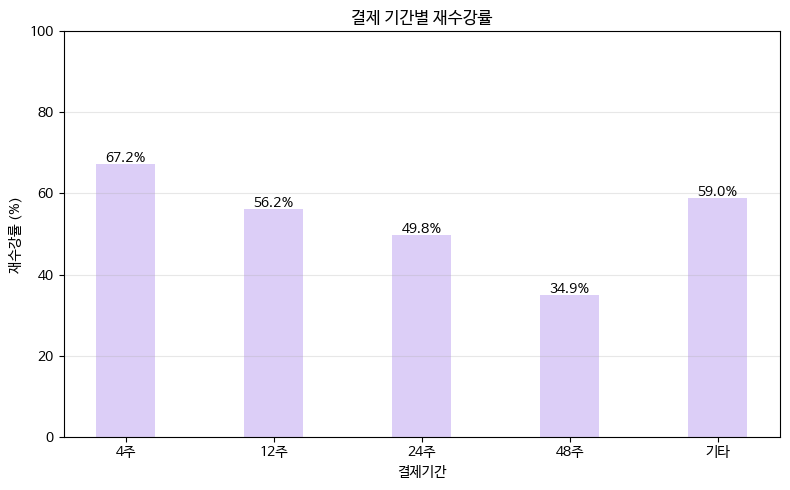

In [20]:
import matplotlib.pyplot as plt

period_rate = (
    df_payment_period
    .groupby('결제기간')['재수강률']
    .mean()
    .mul(100)
    .round(1)
)

order = ['4주', '12주', '24주', '48주', '기타']

period_rate = period_rate.reindex(order)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    period_rate.index,
    period_rate.values,
    width=0.4,
    color='#DCCEF7'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

plt.title('결제 기간별 재수강률')
plt.xlabel('결제기간')
plt.ylabel('재수강률 (%)')

plt.ylim(0, 100)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- 결제 기간이 길어질수록 재수강률이 감소하는 경향이 확인됨
- 4주 상품의 재수강률은 67.2%로 가장 높게 나타남
- 48주 상품의 재수강률은 34.9%로 가장 낮게 나타남
- 학년별 분석 대비 결제 기간에 따른 차이가 상대적으로 크게 나타남
- 결제 기간은 재수강률 변동을 설명할 수 있는 주요 변수 중 하나로 판단됨


### Limitation
- 결제 기간이 긴 상품은 재수강 여부를 결정하는 시점이 상대적으로 늦기 때문에, 결제 기간별 재수강률 차이는 상품 특성의 영향을 일부 포함할 수 있음
- 따라서 본 결과는 결제 기간과 재수강률 간의 관계를 보여주지만, 인과관계를 의미하지는 않음



---



수업 시간에 따른 차이도 검토하였으나, 학년 및 상품 특성과 연관되어 독립적인 변수로 해석하기 어렵다고 판단하여 추가 분석에서는 제외



---



## Analysis 4. 월별 환불률 및 미연장률 추이

### Hypothesis
- 재수강률 하락 시기에도 이탈 유형은 다르게 나타날 수 있음
- 환불 증가와 미연장 증가는 서로 다른 의미를 가지므로, 이탈 유형을 구분하여 확인할 필요가 있음

### Check Points
- 월별 환불률 추이
- 월별 미연장률 추이
- 재수강률 하락 시점과의 관계
- 특정 시기에 환불 또는 미연장이 집중되는지 여부

### Data Preprocessing
- 시스템상 '[미수]' 상태는 미수 기간 종료 후 자동으로 '환불' 처리되지만, 실제 비즈니스 의미는 기간 만료 후 연장을 선택하지 않은 사례에 해당한다. 따라서 본 분석에서는 '[미수]' 상품을 '미연장'으로 재분류하여 분석을 수행하였다.

In [ ]:
# 데이터 전처리

df_leave = df.copy()

# 미수 → 미연장
df_leave.loc[df_leave['상품명'] == '[미수]', '상태'] = '미연장'

df_leave['미연장'] = (df_leave['상태'] == '미연장').astype(int)
df_leave['환불'] = (df_leave['상태'] == '환불').astype(int)

df_leave_monthly = df_leave.groupby('월').agg(
    전체건수=('상태', 'count'),
    미연장=('미연장', 'sum'),
    환불=('환불', 'sum')
).reset_index()

df_leave_monthly['미연장률'] = (df_leave_monthly['미연장'] / df_leave_monthly['전체건수'] * 100).round(1)
df_leave_monthly['환불률'] = (df_leave_monthly['환불'] / df_leave_monthly['전체건수'] * 100).round(1)

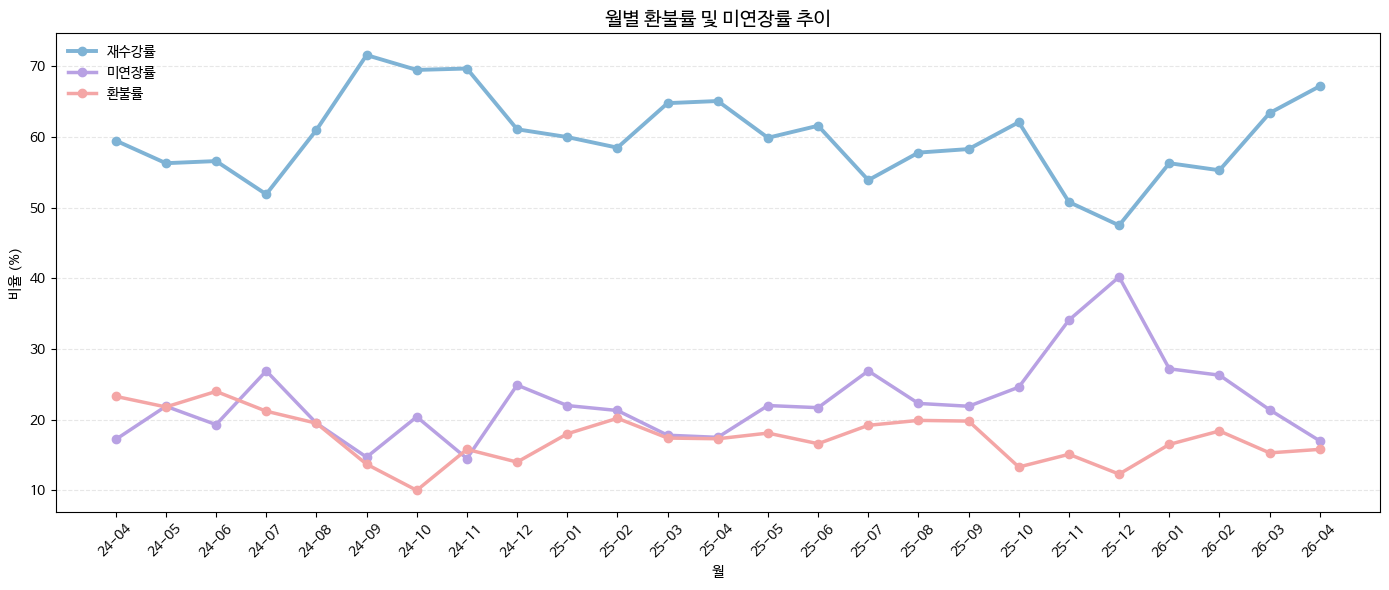

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 재수강률
plt.plot(
    df_monthly['월'],
    df_monthly['재수강률'],
    marker='o',
    linewidth=2.8,
    color='#7FB3D5',
    label='재수강률'
)

# 미연장률
plt.plot(
    df_leave_monthly['월'],
    df_leave_monthly['미연장률'],
    marker='o',
    linewidth=2.5,
    color='#B8A1E3',
    label='미연장률'
)

# 환불률
plt.plot(
    df_leave_monthly['월'],
    df_leave_monthly['환불률'],
    marker='o',
    linewidth=2.5,
    color='#F4A6A6',
    label='환불률'
)

plt.title('월별 환불률 및 미연장률 추이', fontsize=14)
plt.xlabel('월')
plt.ylabel('비율 (%)')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Observation

- 재수강률 하락 구간에서는 환불률보다 미연장률의 증가가 더 두드러짐
- 환불률은 전 기간 동안 10~20% 수준으로 비교적 안정적인 추이를 보임
- 재수강률과 미연장률은 반대 방향으로 움직이는 경향이 나타남
- 재수강률 변동은 환불률보다 미연장률 변화와 더 높은 연관성을 보임

### Limitation
- 미연장은 학생의 선택, 학사 일정 등 다양한 요인이 복합적으로 반영된 결과이므로, 이를 서비스 만족도와 직접 연결하여 해석하기에는 한계가 있음
- 또한, 환불 사유에 대한 세부 데이터가 없어, 환불 발생 원인을 정량적으로 구분하기는 어려움



---



## Conclusion

- 재수강률은 계절성만으로 설명되지 않음
- 학년별 차이는 일부 존재하지만, 일관되지 않음
- 결제 기간은 유의미한 차이를 보임
- 재수강률 하락은 환불보다 미연장의 영향이 큼
- 재수강률 변동은 단일 변수만으로 설명하기 어려우며, 다양한 요인이 복합적으로 작용하는 것으로 판단됨
- 따라서 재수강률 개선을 위해서는 모든 팀에 동일한 액션을 적용하기보다, 팀별 상황과 특성을 고려한 맞춤형 대응이 필요함

> **본 분석은 재수강률 변동 요인을 다각도로 탐색하고, 데이터 기반의 운영 의사결정을 지원하기 위한 근거를 마련하였음**





---



## Business Impact


> 재수강률 변동을 단일 요인이 아닌 다양한 관점에서 해석할 수 있는 분석 체계를 마련하였다. <br>
분석 결과를 바탕으로 팀별 상황을 고려한 운영 방향을 제안하였으며, 운영 개선 방향을 검토하기 위한 근거를 마련하였다.

